# Токенизация по словам

Обучение и сравнение пяти генеративных моделей (Simple RNN, LSTM 1-слойная, LSTM 3-слойная, двунаправленная LSTM, MiniGPT) с использованием **токенизации по словам** на датасете Medium Articles.

In [1]:
import torch
import os
import sys
import re
from collections import Counter

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '.')) if os.path.exists('utils.py') else os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils import load_medium_articles, TextDataset, make_dataloaders, train_model, compute_perplexity, generate_text, plot_training_curves, print_generation_samples
from models import build_all_models, count_parameters

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

Устройство: cuda
GPU: NVIDIA GeForce RTX 4060 Ti

## 1. Загрузка датасета

In [2]:
corpus = load_medium_articles('data/medium_articles.csv', max_articles=5000)
print(f'Пример: {corpus[:300]}')

Загружено 5000 статей, длина корпуса: 28,081,679 символов
Пример: Photo by Josh Riemer on Unsplash

Merry Christmas and Happy Holidays, everyone!

We just wanted everyone to know how much we appreciate everyone and how thankful we are for all our readers and writers here. We wouldn't be anywhere without you, so thank you all for bringing informative, vulnerable, a

## 2. Токенизатор по словам

In [3]:
class WordTokenizer:
    """Токенизатор по словам с фильтрацией по частоте."""

    SPECIAL = {'<PAD>': 0, '<UNK>': 1}

    def __init__(self, corpus, max_vocab=30000, min_freq=3):
        tokens = self._tokenize(corpus)
        freq = Counter(tokens)
        vocab_words = [w for w, c in freq.most_common() if c >= min_freq][:max_vocab - len(self.SPECIAL)]
        self.word2idx = {**self.SPECIAL}
        for w in vocab_words:
            self.word2idx[w] = len(self.word2idx)
        self.idx2word = {i: w for w, i in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)
        print(f'Уникальных токенов в корпусе: {len(freq):,}')
        print(f'Словарь после фильтрации (min_freq={min_freq}): {self.vocab_size:,}')
        total = len(tokens)
        covered = sum(1 for t in tokens if t in self.word2idx)
        print(f'Покрытие: {covered/total*100:.1f}% токенов входят в словарь')

    def _tokenize(self, text):
        return re.findall(r"\\w+|[^\\w\\s]", text.lower())

    def encode(self, text):
        return [self.word2idx.get(w, self.SPECIAL['<UNK>']) for w in self._tokenize(text)]

    def decode(self, ids):
        words = [self.idx2word.get(i, '<UNK>') for i in ids]
        result = []
        for w in words:
            if w in ('<PAD>', '<UNK>'):
                result.append(w)
            elif re.match(r'^[^\\w\\s]$', w) and result:
                result.append(w)
            else:
                result.append(' ' + w if result else w)
        return ''.join(result)


tokenizer = WordTokenizer(corpus, max_vocab=30000, min_freq=3)
print(f'\nРазмер словаря: {tokenizer.vocab_size}')
print(f'Примеры слов: {list(tokenizer.word2idx.keys())[2:22]}')

Уникальных токенов в корпусе: 74,525
Словарь после фильтрации (min_freq=3): 30,000
Покрытие: 98.8% токенов входят в словарь

Размер словаря: 30000
Примеры слов: ['.', ',', 'the', 'to', 'and', 'a', 'of', ''', 'in', 'is', 'that', 'you', 'i', 'it', '-', 'for', 'we', 's', 'with', 'on']

In [4]:
# Кодирование корпуса
token_ids = tokenizer.encode(corpus)
print(f'Всего токенов: {len(token_ids):,}')
print(f'Первые 30 id: {token_ids[:30]}')
print(f'Декодировано обратно: {tokenizer.decode(token_ids[:30])}')

Всего токенов: 5,747,324
Первые 30 id: [356, 36, 8183, 1, 21, 509, 12025, 2216, 6, 849, 5064, 3, 439, 117, 18, 83, 554, 439, 5, 110, 55, 127, 18, 2648, 439, 6, 55, 7815, 18, 26]
Декодировано обратно: photo by josh<UNK> on unsplash merry christmas and happy holidays, everyone! we just wanted everyone to know how much we appreciate everyone and how thankful we are

## 3. Создание DataLoader'ов

In [5]:
SEQ_LEN = 64
BATCH_SIZE = 256

train_dl, val_dl = make_dataloaders(token_ids, SEQ_LEN, BATCH_SIZE, val_split=0.1)
print(f'Батчей на эпоху — train: {len(train_dl)}, val: {len(val_dl)}')

Последовательностей — train: 80821, val: 8980
Батчей на эпоху — train: 315, val: 35

## 4. Построение моделей

In [6]:
EMBED_DIM = 256
HIDDEN_DIM = 512
GPT_DIM = 256
GPT_HEADS = 4
GPT_LAYERS = 4
GPT_FF = 512

models = build_all_models(
    vocab_size=tokenizer.vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    gpt_dim=GPT_DIM,
    gpt_heads=GPT_HEADS,
    gpt_layers=GPT_LAYERS,
    gpt_ff=GPT_FF,
    max_seq_len=SEQ_LEN,
)

for name, model in models.items():
    print(f'{name}: {count_parameters(model):,} параметров')

SimpleRNN: 23,464,240 параметров
LSTM_1layer: 24,646,960 параметров
LSTM_3layer: 28,849,456 параметров
BiLSTM: 47,883,568 параметров
MiniGPT: 9,805,312 параметров

## 4б. Загрузка сохранённых чекпойнтов (пропуск обучения)

In [7]:
# Загрузка чекпойнтов вместо повторного обучения.
# Ячейки 1-4 выше должны быть выполнены (токенизатор + модели).

SAVE_DIR = 'checkpoints/word'
loaded = []
for name, model in models.items():
    ckpt = os.path.join(SAVE_DIR, f'word_{name}_best.pt')
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        loaded.append(name)
        print(f'Загружена {name} из {ckpt}')
    else:
        print(f'ВНИМАНИЕ: чекпойнт не найден для {name} по пути {ckpt}')

print(f'\nЗагружено моделей: {len(loaded)}/{len(models)}')

Загружена SimpleRNN из checkpoints/word/word_SimpleRNN_best.pt
Загружена LSTM_1layer из checkpoints/word/word_LSTM_1layer_best.pt
Загружена LSTM_3layer из checkpoints/word/word_LSTM_3layer_best.pt
Загружена BiLSTM из checkpoints/word/word_BiLSTM_best.pt
Загружена MiniGPT из checkpoints/word/word_MiniGPT_best.pt

Загружено моделей: 5/5

## 5. Обучение всех моделей

In [7]:
EPOCHS = 15
PATIENCE = 5
SAVE_DIR = 'checkpoints/word'

histories = {}

training_config = {
    'SimpleRNN':   {'lr': 1e-3, 'use_amp': False},
    'LSTM_1layer': {'lr': 1e-3, 'use_amp': False},
    'LSTM_3layer': {'lr': 1e-3, 'use_amp': False},
    'BiLSTM':      {'lr': 1e-3, 'use_amp': False},
    'MiniGPT':     {'lr': 3e-4, 'use_amp': True},
}

In [8]:
for name, model in models.items():
    print(f'\nОбучение {name}')
    print('-' * 40)
    cfg = training_config[name]
    histories[name] = train_model(
        model, train_dl, val_dl,
        epochs=EPOCHS,
        lr=cfg['lr'],
        device=DEVICE,
        use_amp=cfg['use_amp'],
        patience=PATIENCE,
        model_name=f'word_{name}',
        save_dir=SAVE_DIR,
    )

Обучение SimpleRNN
----------------------------------------
  [word_SimpleRNN] Epoch 1: train_loss=6.2914  val_loss=5.7808  val_ppl=324.03
  [word_SimpleRNN] Epoch 2: train_loss=5.4814  val_loss=5.5071  val_ppl=246.44
  [word_SimpleRNN] Epoch 3: train_loss=5.2258  val_loss=5.3910  val_ppl=219.43
  [word_SimpleRNN] Epoch 4: train_loss=5.0709  val_loss=5.3231  val_ppl=205.01
  [word_SimpleRNN] Epoch 5: train_loss=4.9561  val_loss=5.2874  val_ppl=197.82
  [word_SimpleRNN] Epoch 6: train_loss=4.8672  val_loss=5.2662  val_ppl=193.69
  [word_SimpleRNN] Epoch 7: train_loss=4.7923  val_loss=5.2493  val_ppl=190.44
  [word_SimpleRNN] Epoch 8: train_loss=4.7300  val_loss=5.2364  val_ppl=188.00
  [word_SimpleRNN] Epoch 9: train_loss=4.6768  val_loss=5.2335  val_ppl=187.44
  [word_SimpleRNN] Epoch 10: train_loss=4.6304  val_loss=5.2361  val_ppl=187.93
  [word_SimpleRNN] Epoch 11: train_loss=4.5888  val_loss=5.2349  val_ppl=187.71
  [word_SimpleRNN] Epoch 12: train_loss=4.5518  val_loss=5.2370  val_

## 6. Кривые обучения

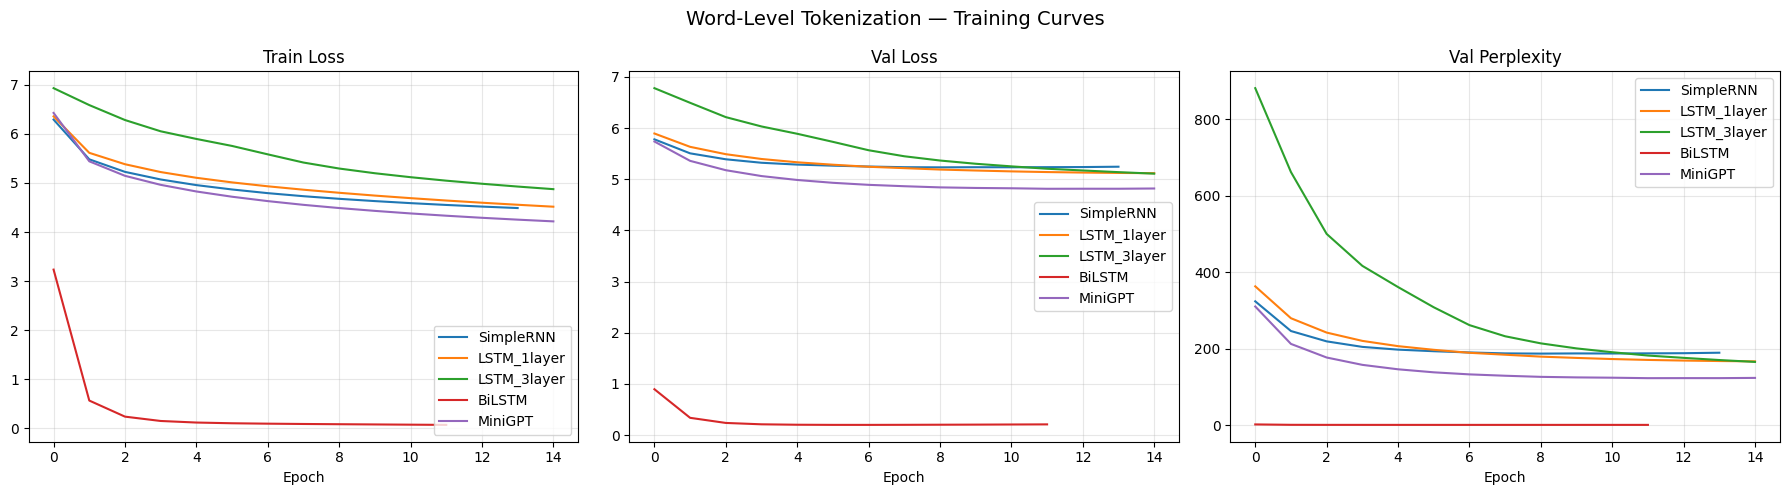

In [9]:
plot_training_curves(histories, title='Word-Level Tokenization — Training Curves')

## 7. Итоговое сравнение перплексии

In [10]:
print(f'{"Модель":<20} {"Перплексия":<15} {"Параметры":<15}')
print('-' * 50)
for name, model in models.items():
    ppl = compute_perplexity(model, val_dl, device=DEVICE, use_amp=('GPT' in name))
    params = count_parameters(model)
    print(f'{name:<20} {ppl:<15.2f} {params:<15,}')

Модель               Перплексия      Параметры
--------------------------------------------------
SimpleRNN            187.44          23,464,240
LSTM_1layer          167.21          24,646,960
LSTM_3layer          165.73          28,849,456
BiLSTM               1.22            47,883,568
MiniGPT              123.29          9,805,312

## 8. Примеры генерации текста

In [11]:
seed_text = 'the future of artificial intelligence '
seed_ids = tokenizer.encode(seed_text)
print(f'Сид: "{seed_text}"')
print(f'Количество токенов: {len(seed_ids)}')
print(f'ID токенов: {seed_ids}')

Сид: "the future of artificial intelligence "
Количество токенов: 5
ID токенов: [4, 319, 8, 805, 569]

In [12]:
samples = {}
for name, model in models.items():
    samples[name] = generate_text(
        model, seed_ids, tokenizer.decode,
        length=100, temperature=0.8, top_k=50,
        device=DEVICE, max_context=SEQ_LEN,
    )

print_generation_samples(samples, title='Примеры генерации (токенизация по словам)')

Примеры генерации (токенизация по словам)

--- SimpleRNN ---
the future of artificial intelligence, but that can be used to measure the outcome of the virus. since the pandemic, we should be able to create different ways to produce these people— the more important for the past, so they do you need to invest as much as possible. they do not have to spend 20 hours at your time, but it' s a pretty small job you' ll need to know how to get a good life. the process that doesn' t matter if you' re going to write as a technical

--- LSTM_1layer ---
the future of artificial intelligence? it would be a great way to do data science, which is why it is not what we say, but what' s the biggest problem? how that is a natural tool? for example, let' s take a look at the edge of our work and the world is the first step in the process. when we find it helpful, it' s a great way to understand how many of your emotions and will increase your mood when you get it. i don' t want to worry about

--- LSTM_3

## 9. Генерация при различных температурах

In [13]:
# Влияние температуры на лучшую модель (MiniGPT)
best_model = models['MiniGPT']
for temp in [0.3, 0.5, 0.8, 1.0, 1.2]:
    text = generate_text(
        best_model, seed_ids, tokenizer.decode,
        length=80, temperature=temp, top_k=50,
        device=DEVICE, max_context=SEQ_LEN,
    )
    print(f'\n--- Температура = {temp} ---')
    print(text[:400])

--- Температура = 0.3 ---
the future of artificial intelligence, is the most important thing to do is to be able to get the most accurate results. the idea of the ai is that it will be a good idea. it is a good idea to get the right idea to help you get the right time. it' s important to remember that the ai is a great idea to do it. it' s a good idea to be able to get the

--- Температура = 0.5 ---
the future of artificial intelligence? and how do you think about the current ai and ai? ai is a human- centered design tool that allows us to design a new ai system to create a new ai system. ai has a basic understanding of ai and artificial intelligence. but the most important thing is to be a human, and it is that it is not a real- world interface. in reality, ai can be used to

--- Температура = 0.8 ---
the future of artificial intelligence. this"<UNK>" is the most obvious part of the company in the game. it was the second approach for this technology. for the meantime, i was able to fo

## 10. Итоги

| Модель | Val Loss | Val Perplexity | Параметры |
|--------|----------|----------------|-----------|
| SimpleRNN | 5.233 | 187.44 | 23 464 240 |
| LSTM (1 слой) | 5.119 | 167.21 | 24 646 960 |
| LSTM (3 слоя) | 5.110 | 165.73 | 28 849 456 |
| Bidirectional LSTM | 0.199 | 1.22 | 47 883 568 |
| MiniGPT | 4.815 | 123.29 | 9 805 312 |

**Лучшая модель по перплексии:** MiniGPT (123.29) — среди однонаправленных моделей, пригодных для генерации.

> **Примечание:** BiLSTM показывает аномально низкую перплексию (~1.22), так как двунаправленная архитектура «видит» будущие токены. Это делает её непригодной для авторегрессионной генерации, но формально она минимизирует loss лучше всех.